# Constructing EOS and solving TOV equations — Skyrme only


This example notebook shows how to construct the equation of state using the Skyrme EOS parametrisation, as well as solve the TOV equations.

Unlike the companion notebook `eos_tov_skyrme.ipynb`, this version uses only the baseline Skyrme without the speed-of-sound extension (CSE). The density range is therefore limited to the Skyrme region (up to `nmax_nsat`).


In [1]:
import matplotlib.pyplot as plt

params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Serif"],
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
}
plt.rcParams.update(params)

import jax.numpy as jnp

import jesterTOV
from jesterTOV.eos.skyrme import Skyrme_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.data_classes import EOSData
import jesterTOV.utils as utils


# Equation of state


In [ ]:
nsat = 0.16  # nuclear saturation density in fm^-3

# Define the EOS object — the baseline Skyrme without CSE
# Two proton-fraction treatments are compared:
#   exact (default / None): beta-equilibrium with muons
#   approx: fast approximate proton fraction (no muons)
eos = Skyrme_EOS_model(nmax_nsat=8.0)
eos_approx = Skyrme_EOS_model(nmax_nsat=8.0, proton_fraction="approx")

INM_dict = {'t2': 0.03044793589402975, 't4': -449.690011388705, 'x0': -0.3807363799943084, 'x1': 2.9824061641636304, 'x4': 2.9894128176264516, 'alph': 0.09293364608599916, 'beta': 0.23545028701326712, 'gamma': 0.06609969612346187, 'kfsat': 1.3221037208152984, 'av': -16.94238227898348, 'J': 38.760958598892934, 'meffs': 0.7632119995224719, 'meffv': 0.7682601630809389, 'Kinf': 229.57210028515922, 'eNMhd': 238.2224215086287}

ns, ps, hs, es, dloge_dlogps, mu, cs2, extra = eos.construct_eos(INM_dict, return_extra=True, calculate_durca=True)
ns_approx, ps_approx, hs_approx, es_approx, dloge_dlogps_approx, mu_approx, cs2_approx, extra_approx = eos_approx.construct_eos(INM_dict, return_extra=True)

eos_data = EOSData(ns=ns, ps=ps, hs=hs, es=es, dloge_dlogps=dloge_dlogps, cs2=cs2, mu=mu, extra_constraints=extra)
eos_data_approx = EOSData(ns=ns_approx, ps=ps_approx, hs=hs_approx, es=es_approx, dloge_dlogps=dloge_dlogps_approx, cs2=cs2_approx, mu=mu_approx, extra_constraints=extra_approx)

# Extract extra info for diagnostics
n_orig = extra["n_orig"]
proton_fraction = extra["proton_fraction"]
e_fraction = extra["e_fraction"]
muon_fraction = extra["muon_fraction"]
durca_density = extra["durca_density"]

proton_fraction_approx = extra_approx["proton_fraction"]
n_orig_approx = extra_approx["n_orig"]

# Find the density where the EOS becomes acausal (cs2 >= 1 or cs2 < 0).
cs2_full = cs2
ns_full_geom = ns
acausal_mask = (cs2_full >= 1.0) | (cs2_full < 0.0)
nbreak_geom = ns_full_geom[jnp.argmax(acausal_mask)]
nbreak = nbreak_geom / utils.fm_inv3_to_geometric   # now in fm^-3

print("-" * 50)
ye_durca = durca_density["ye"]
ym_durca = durca_density["ym"]
n_durca = durca_density["nb_durca"]

print("--- DUrca Threshold Results ---")
print(f"Ye            : {ye_durca:.6f}")
print(f"Ymu           : {ym_durca:.6f}")
print(f"Yp (Total)    : {ye_durca + ym_durca:.6f}")
print(f"n_b/n_sat     : {n_durca / nsat:.4f}")
print("--- Causality Limit ---")
print(f"n_break/n_sat : {nbreak / nsat:.4f}")
print("-" * 50)

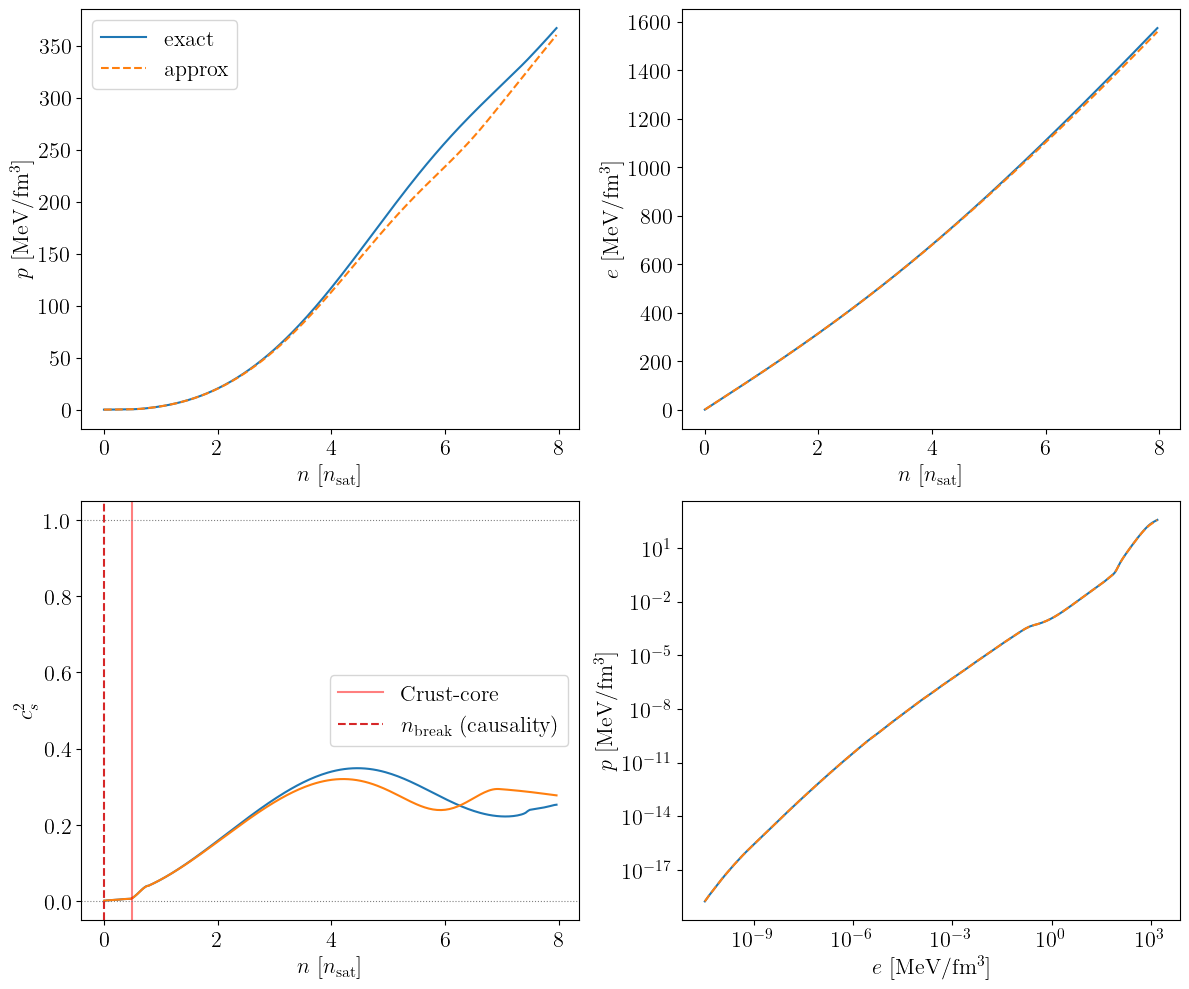

In [3]:
# Unpack the EOSData NamedTuples
ns, ps, hs, es, dloge_dlogps = (
    eos_data.ns,
    eos_data.ps,
    eos_data.hs,
    eos_data.es,
    eos_data.dloge_dlogps,
)
cs2, mu = eos_data.cs2, eos_data.mu

ns_a, ps_a, hs_a, es_a, dloge_dlogps_a = (
    eos_data_approx.ns,
    eos_data_approx.ps,
    eos_data_approx.hs,
    eos_data_approx.es,
    eos_data_approx.dloge_dlogps,
)
cs2_a, mu_a = eos_data_approx.cs2, eos_data_approx.mu

# Convert to common units for plotting
ns_plots = ns / utils.fm_inv3_to_geometric / nsat
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

ns_plots_approx = ns_a / utils.fm_inv3_to_geometric / nsat
es_plots_approx = es_a / utils.MeV_fm_inv3_to_geometric
ps_plots_approx = ps_a / utils.MeV_fm_inv3_to_geometric

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# p(n)
axes[0, 0].plot(ns_plots, ps_plots, label="exact")
axes[0, 0].plot(ns_plots_approx, ps_plots_approx, "--", label="approx")
axes[0, 0].set_xlabel(r"$n$ [$n_{\rm{sat}}$]")
axes[0, 0].set_ylabel(r"$p$ [MeV/fm$^3$]")
axes[0, 0].legend()

# e(n)
axes[0, 1].plot(ns_plots, es_plots)
axes[0, 1].plot(ns_plots_approx, es_plots_approx, "--")
axes[0, 1].set_xlabel(r"$n$ [$n_{\rm{sat}}$]")
axes[0, 1].set_ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
axes[1, 0].plot(ns_plots, cs2)
axes[1, 0].plot(ns_plots_approx, cs2_a)
axes[1, 0].axvline(0.5, color="red", alpha=0.5, label=r"Crust-core")
axes[1, 0].axvline(nbreak / nsat, color="tab:red", ls="--", lw=1.5, label=r"$n_{\rm{break}}$ (causality)")
axes[1, 0].axhline(0.0, color="gray", ls=":", lw=0.8)
axes[1, 0].axhline(1.0, color="gray", ls=":", lw=0.8)
axes[1, 0].set_xlabel(r"$n$ [$n_{\rm{sat}}$]")
axes[1, 0].set_ylabel(r"$c_s^2$")
axes[1, 0].legend()

# p(e)
axes[1, 1].plot(es_plots, ps_plots)
axes[1, 1].plot(es_plots_approx, ps_plots_approx, "--")
axes[1, 1].set_xlabel(r"$e$ [MeV/fm$^3$]")
axes[1, 1].set_ylabel(r"$p$ [MeV/fm$^3$]")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xscale("log")

fig.tight_layout()
plt.show()
plt.close(fig)


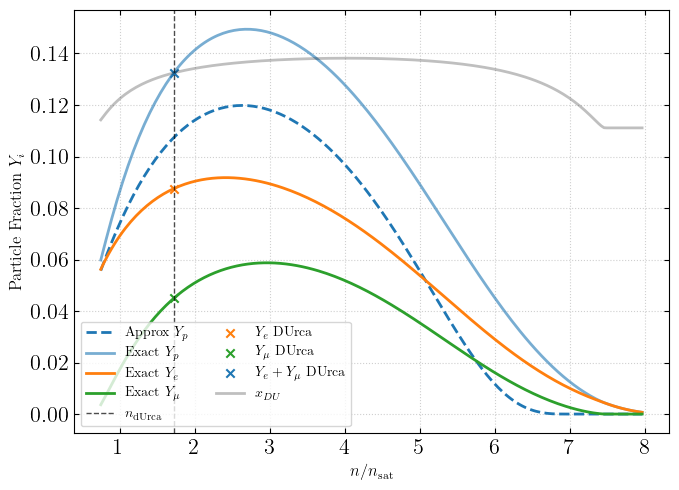

In [4]:
# Compare exact vs approximate proton fraction
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    n_orig / nsat,
    proton_fraction_approx,
    ls="--",
    lw=2,
    color="tab:blue",
    label=r"Approx $Y_p$",
)
ax.plot(
    n_orig / nsat,
    proton_fraction,
    ls="-",
    lw=2,
    color="tab:blue",
    alpha=0.6,
    label=r"Exact $Y_p$",
)
if e_fraction is not None:
    ax.plot(
        n_orig / nsat,
        e_fraction,
        ls="-",
        lw=2,
        color="tab:orange",
        label=r"Exact $Y_e$",
    )
if muon_fraction is not None:
    ax.plot(
        n_orig / nsat,
        muon_fraction,
        ls="-",
        lw=2,
        color="tab:green",
        label=r"Exact $Y_{\mu}$",
    )

ax.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=12)
ax.set_ylabel(r"Particle Fraction $Y_i$", fontsize=12)
ax.axvline(
    x=n_durca / nsat,
    color="black",
    ls="--",
    linewidth=1.0,
    alpha=0.7,
    label=r"$n_{\rm{dUrca}}$",
)
ax.scatter(n_durca / nsat, ye_durca, color="tab:orange", marker="x", label=r"$Y_{e}$ DUrca")
ax.scatter(
    n_durca / nsat, ym_durca, color="tab:green", marker="x", label=r"$Y_{\mu}$ DUrca"
)
ax.scatter(
    n_durca / nsat,
    ye_durca + ym_durca,
    color="tab:blue",
    marker="x",
    label=r"$Y_{e} + Y_{\mu}$ DUrca",
)

# DU fraction diagnostic
if e_fraction is not None and muon_fraction is not None:
    x_e = e_fraction / (e_fraction + muon_fraction)
    x_DU = 1 / (1 + (1 + jnp.cbrt(x_e)) ** 3)
    ax.plot(
        n_orig / nsat,
        x_DU,
        ls="-",
        lw=2,
        color="k",
        alpha=0.25,
        label=r"$x_{DU}$",
    )

ax.grid(True, which="major", linestyle=":", alpha=0.6)
ax.legend(frameon=True, loc="best", fontsize=10, ncol=2)
fig.tight_layout()
plt.show()
plt.close(fig)


# Neutron stars


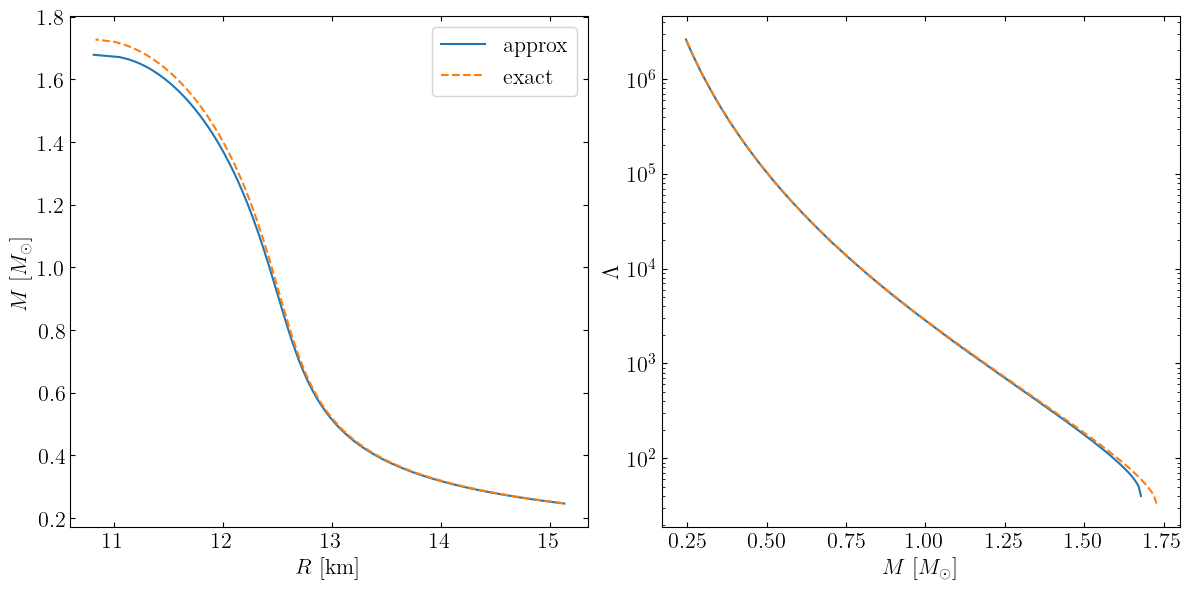

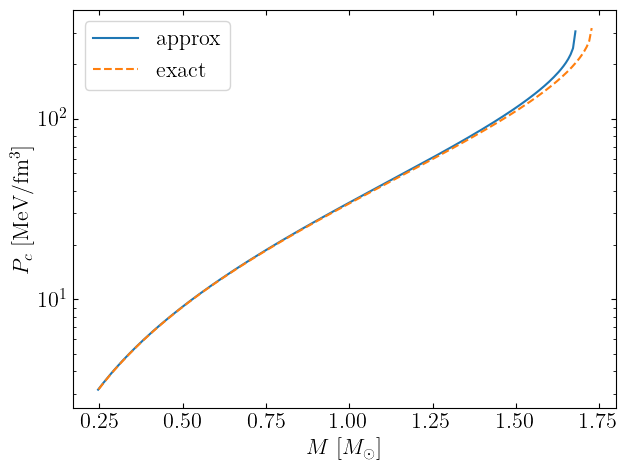

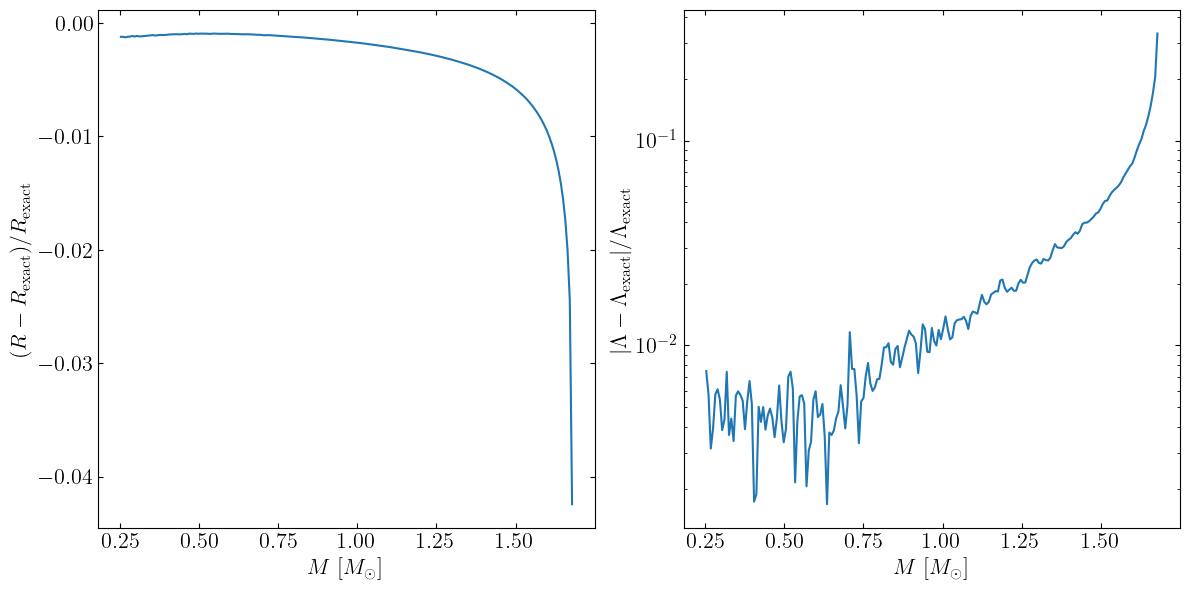

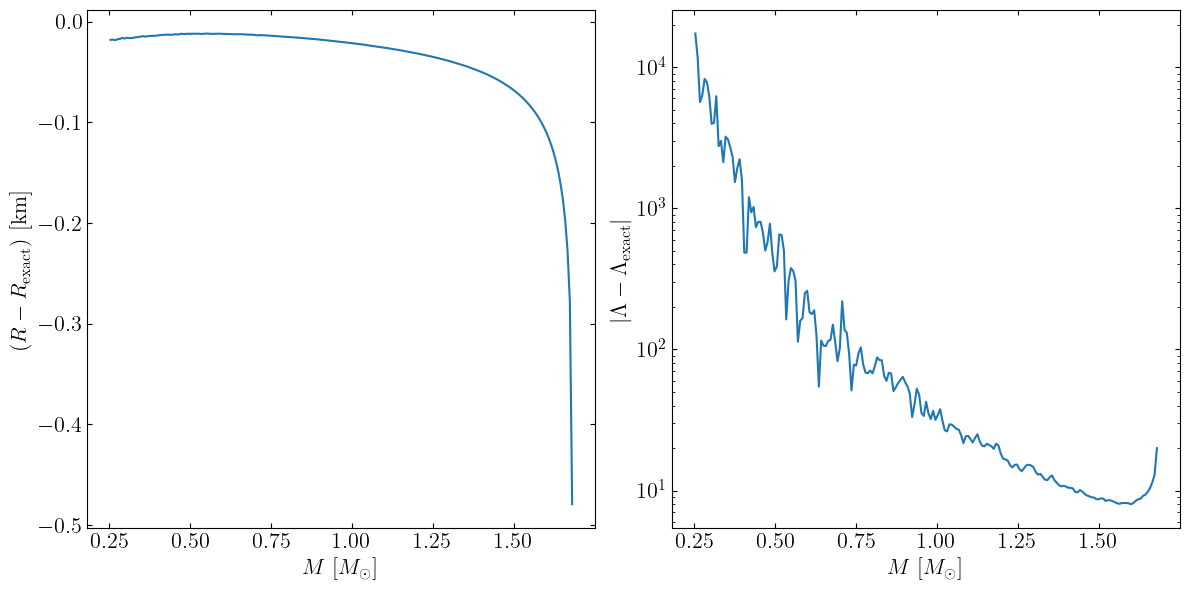

In [5]:
from scipy.interpolate import interp1d
from jesterTOV.tov.data_classes import EOSData


def truncate_to_causal(eos_data_in):
    """Slice EOSData to keep only the causal region (cs2 in [0, 1])."""
    cs2_arr = eos_data_in.cs2
    acausal = (cs2_arr >= 1.0) | (cs2_arr < 0.0)
    if bool(jnp.any(acausal)):
        last = int(jnp.argmax(acausal))
    else:
        last = len(cs2_arr)
    return EOSData(
        ns=eos_data_in.ns[:last],
        ps=eos_data_in.ps[:last],
        hs=eos_data_in.hs[:last],
        es=eos_data_in.es[:last],
        dloge_dlogps=eos_data_in.dloge_dlogps[:last],
        cs2=eos_data_in.cs2[:last],
        mu=eos_data_in.mu[:last] if eos_data_in.mu is not None else None,
        extra_constraints=eos_data_in.extra_constraints,
    )


# Truncate to causal region
eos_data_causal = truncate_to_causal(eos_data)
eos_data_approx_causal = truncate_to_causal(eos_data_approx)

# Solve TOV equations for both EOS variants
solver = GRTOVSolver()

family = solver.construct_family(eos_data_causal, ndat=200, min_nsat=1.0, tov_params={})
log10pcs, masses, radii, Lambdas = (
    family.log10pcs,
    family.masses,
    family.radii,
    family.lambdas,
)

family_approx = solver.construct_family(
    eos_data_approx_causal, ndat=200, min_nsat=1.0, tov_params={}
)
log10pcs_a, masses_a, radii_a, Lambdas_a = (
    family_approx.log10pcs,
    family_approx.masses,
    family_approx.radii,
    family_approx.lambdas,
)

# Interpolate the exact solution at the approximate mass points for comparison
f_exact = interp1d(masses, radii, kind="cubic", bounds_error=False)
f_exact_lam = interp1d(masses, Lambdas, kind="cubic", bounds_error=False)
radii_exact_interp = f_exact(masses_a)
Lambdas_exact_interp = f_exact_lam(masses_a)
radius_diff = radii_a - radii_exact_interp
Lambdas_diff = Lambdas_a - Lambdas_exact_interp

# --- M(R) and M(Lambda) ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].plot(radii_a, masses_a, label="approx")
axes[0].plot(radii, masses, "--", label="exact")
axes[0].set_xlabel(r"$R$ [km]")
axes[0].set_ylabel(r"$M$ [$M_\odot$]")
axes[0].legend()

axes[1].plot(masses_a, Lambdas_a, label="approx")
axes[1].plot(masses, Lambdas, "--", label="exact")
axes[1].set_xlabel(r"$M$ [$M_\odot$]")
axes[1].set_ylabel(r"$\Lambda$")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()
plt.close(fig)

# --- Central pressure vs mass ---
plt.plot(masses_a, jnp.power(10, log10pcs_a) / utils.MeV_fm_inv3_to_geometric, label="approx")
plt.plot(masses, jnp.power(10, log10pcs) / utils.MeV_fm_inv3_to_geometric, "--", label="exact")
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$P_c$ [MeV/fm$^3$]")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# --- Fractional differences ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].plot(masses_a, radius_diff / radii_exact_interp)
axes[0].set_ylabel(r"$(R-R_{\rm{exact}})/R_{\rm{exact}}$")
axes[0].set_xlabel(r"$M$ [$M_\odot$]")

axes[1].plot(masses_a, jnp.abs(Lambdas_diff / Lambdas_exact_interp))
axes[1].set_xlabel(r"$M$ [$M_\odot$]")
axes[1].set_ylabel(r"$|\Lambda-\Lambda_{\rm{exact}}|/\Lambda_{\rm{exact}}$")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()
plt.close(fig)

# --- Absolute differences ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].plot(masses_a, radius_diff)
axes[0].set_ylabel(r"$(R-R_{\rm{exact}})$ [km]")
axes[0].set_xlabel(r"$M$ [$M_\odot$]")

axes[1].plot(masses_a, jnp.abs(Lambdas_diff))
axes[1].set_xlabel(r"$M$ [$M_\odot$]")
axes[1].set_ylabel(r"$|\Lambda-\Lambda_{\rm{exact}}|$")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()
plt.close(fig)


🩹 Applying JIT-safe monkey patch to Crust._preprocess...
✅ Patch applied. You can now run JAX JIT without dynamic shape errors.
Running 1024 EOS constructions in parallel...

NaN Detection Results (Unpacked 8 variables):

Variable 'ps': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'hs': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'es': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'dloge_dlogps': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'mu': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'cs2': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'durca['e_fraction']': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Variable 'durca['proton_fraction']': 317 tests with NaN
  Indices: [1, 2, 5, 10, 11, 15, 16, 19, 21, 24]...

Summary: 707/1024 successful, 31

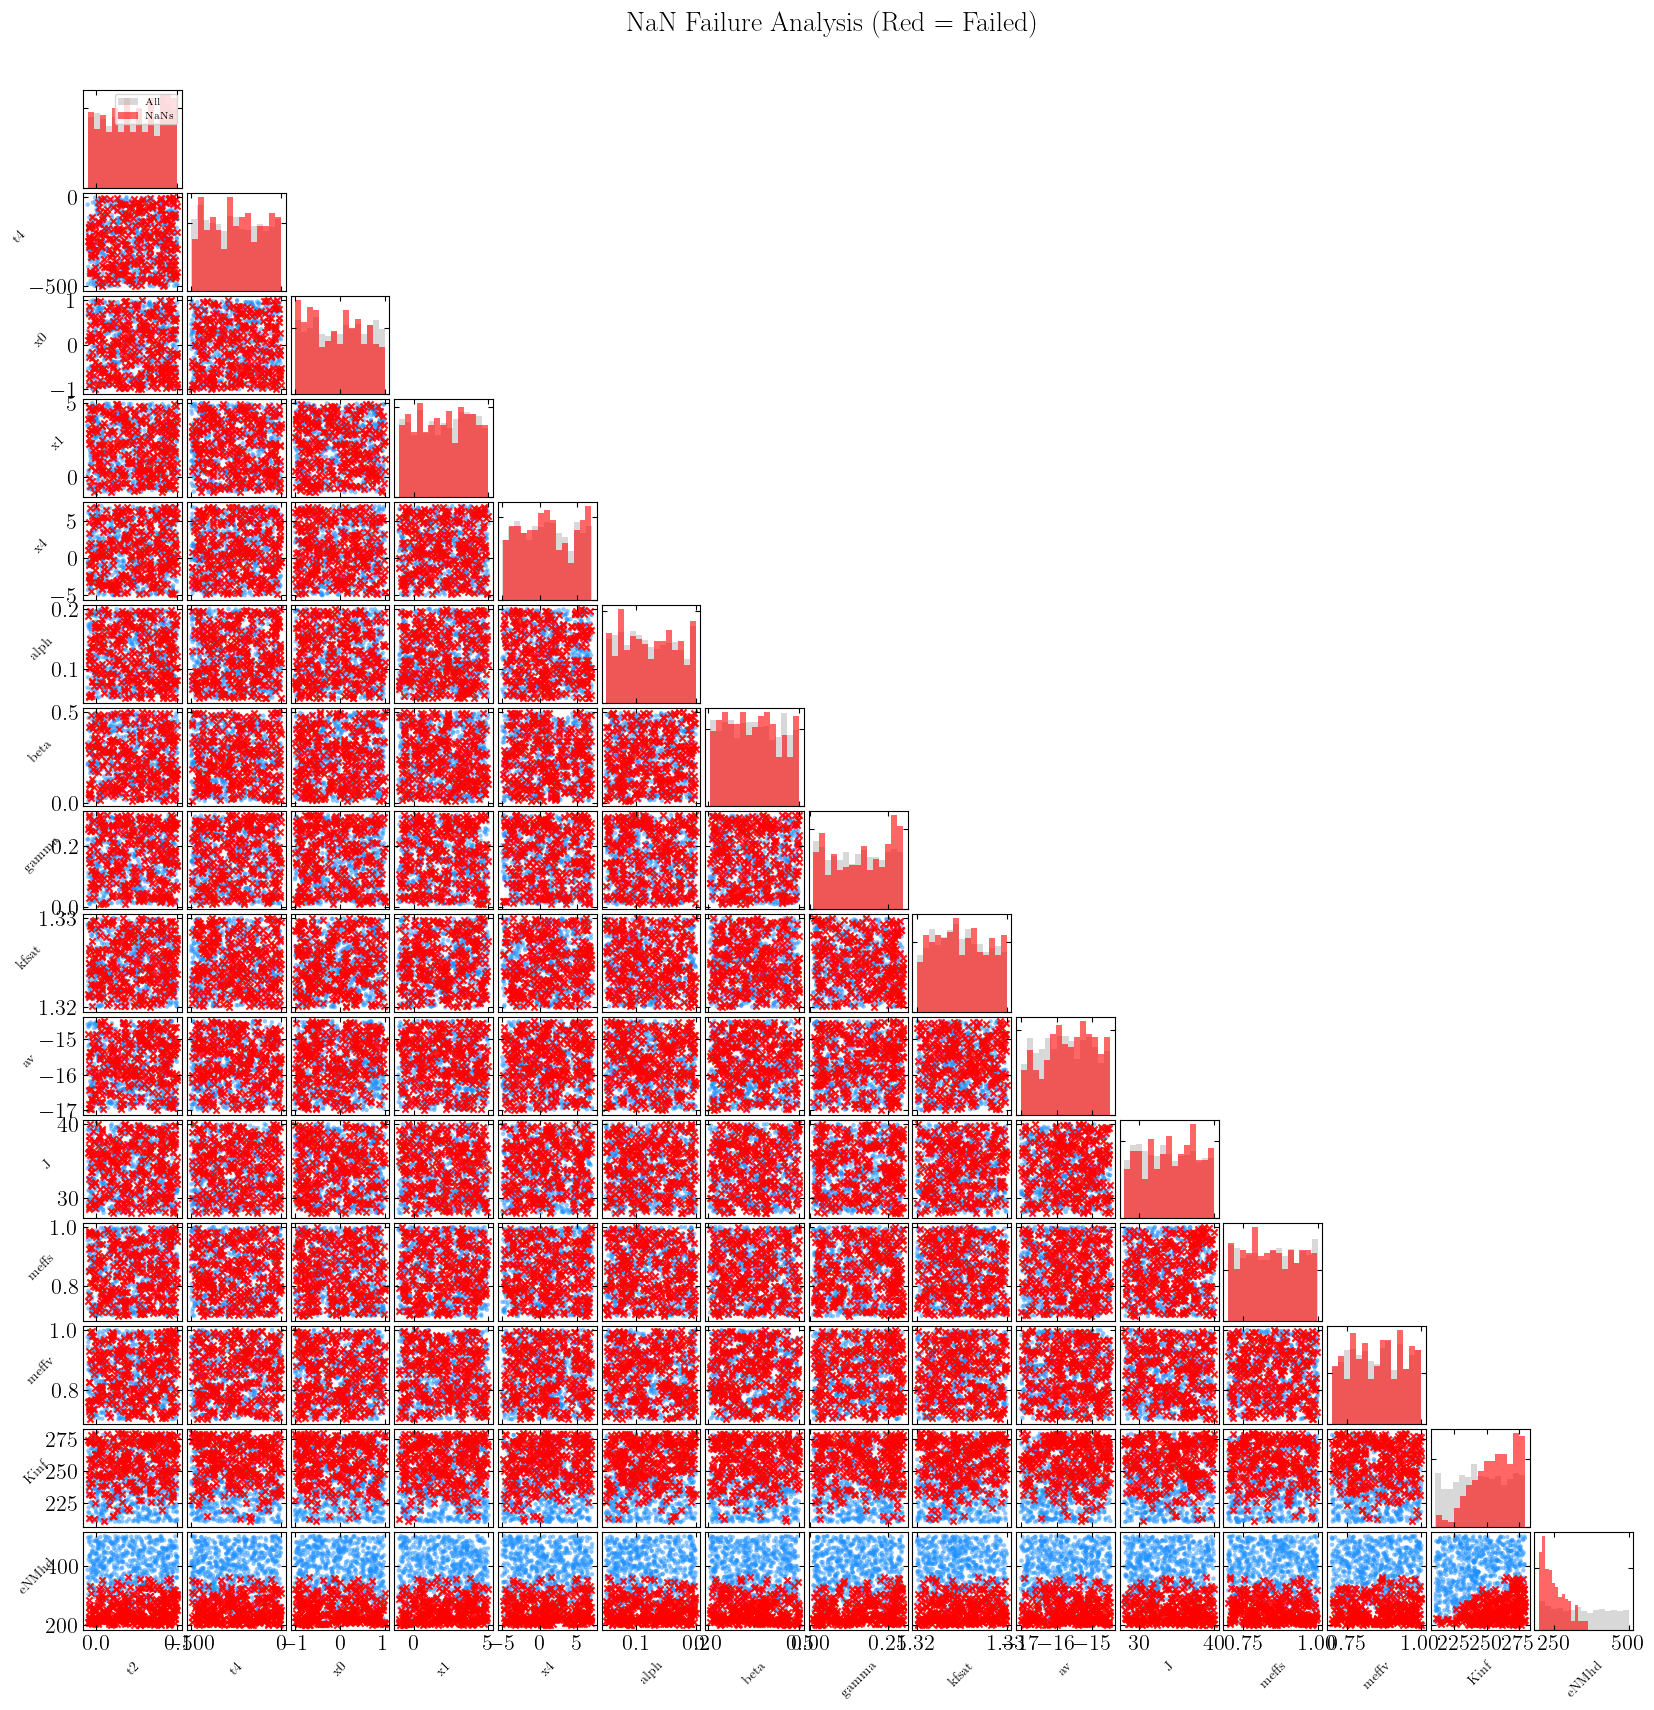

In [6]:
import numpy as np
import jax
import jax.numpy as jnp

# ---------------------------------------------------------
# MONKEY PATCH: Fix Dynamic Shape Error without editing files
# ---------------------------------------------------------
from jesterTOV.eos.crust import Crust


def safe_preprocess(self, n, p, e, min_density, max_density, filter_zero_pressure):
    return n, p, e


print("\U0001fa79 Applying JIT-safe monkey patch to Crust._preprocess...")
Crust._preprocess = safe_preprocess
print("\u2705 Patch applied. You can now run JAX JIT without dynamic shape errors.")

# ---------------------------------------------------------
# 1. Setup Parameters (Skyrme INM parameters)
# ---------------------------------------------------------
inm_ranges = {
    "t2": (-1e-2, 1e-1),
    "t4": (-500, 0),
    "x0": (-1.0, 1),
    "x1": (-1.0, 5.0),
    "x4": (-5.0, 7.0),
    "alph": (0.05, 0.2),
    "beta": (0.01, 0.5),
    "gamma": (0.01, 0.3),
    "kfsat": (1.32, 1.33),
    "av": (-17.0, -14.5),
    "J": (28.0, 40.0),
    "meffs": (0.7, 1.0),
    "meffv": (0.7, 1.0),
    "Kinf": (210.0, 280.0),
    "eNMhd": (200.0, 500.0),
}
param_names = list(inm_ranges.keys())
n_tests = 1024
np.random.seed(42)

n_params = len(param_names)
bounds = np.array([inm_ranges[p] for p in param_names])
random_params = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_tests, n_params))

inm_batch = {
    name: jnp.array(random_params[:, i])
    for i, name in enumerate(param_names)
}

nsat = 0.16

@jax.jit
def run_batch_eos(inm_batch):
    """Runs construct_eos for the entire batch at once."""
    def single_step(inm):
        return eos.construct_eos(
            inm,
            return_extra=True,
            calculate_durca=False,
        )
    batch_fn = jax.vmap(single_step)
    return batch_fn(inm_batch)

# ---------------------------------------------------------
# 4. Execution
# ---------------------------------------------------------
print(f"Running {n_tests} EOS constructions in parallel...")
results = run_batch_eos(inm_batch)

# ---------------------------------------------------------
# 5. NaN Detection
# ---------------------------------------------------------
ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, *extras = results

if extras:
    durca_all = extras[0]
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2', 'durca']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, durca_all]
else:
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all]

print(f"\n{'='*60}")
print(f"NaN Detection Results (Unpacked {len(all_outputs)} variables):")
print(f"{'='*60}")

total_nan_tests = 0
global_nan_mask = jnp.zeros(n_tests, dtype=bool)

for name, arr in zip(output_names, all_outputs):
    if isinstance(arr, dict):
        for sub_key, sub_arr in arr.items():
            full_name = f"{name}['{sub_key}']"
            if not hasattr(sub_arr, 'shape'):
                continue
            if sub_arr.ndim > 1:
                row_is_nan = jnp.any(jnp.isnan(sub_arr), axis=tuple(range(1, sub_arr.ndim)))
            else:
                row_is_nan = jnp.isnan(sub_arr)
            global_nan_mask = global_nan_mask | row_is_nan
            nan_count = jnp.sum(row_is_nan)
            if nan_count > 0:
                indices = jnp.where(row_is_nan)[0]
                print(f"\nVariable '{full_name}': {nan_count} tests with NaN")
                print(f"  Indices: {indices[:10].tolist()}{'...' if len(indices)>10 else ''}")
        continue

    if not hasattr(arr, 'ndim'):
        continue

    if arr.ndim > 1:
        row_is_nan = jnp.any(jnp.isnan(arr), axis=tuple(range(1, arr.ndim)))
    else:
        row_is_nan = jnp.isnan(arr)

    global_nan_mask = global_nan_mask | row_is_nan
    nan_count = jnp.sum(row_is_nan)
    if nan_count > 0:
        indices = jnp.where(row_is_nan)[0]
        print(f"\nVariable '{name}': {nan_count} tests with NaN")
        print(f"  Indices: {indices[:10].tolist()}{'...' if len(indices)>10 else ''}")

total_fails = jnp.sum(global_nan_mask)
successful = n_tests - total_fails

print(f"\n{'='*60}")
print(f"Summary: {successful}/{n_tests} successful, {total_fails}/{n_tests} failed.")
if total_fails > 0:
    first_fail_idx = int(jnp.where(global_nan_mask)[0][0])
    print(f"First failing parameters (Index {first_fail_idx}):")
    bad_params = {k: float(v[first_fail_idx]) for k, v in inm_batch.items()}
    print(bad_params)
print(f"{'='*60}")

# ---------------------------------------------------------
# 6. Corner Plot
# ---------------------------------------------------------
import matplotlib.pyplot as plt

param_matrix = np.stack([np.array(inm_batch[p]) for p in param_names], axis=1)
is_bad = np.array(global_nan_mask)
is_good = ~is_bad

n_dims = len(param_names)
fig, axes = plt.subplots(n_dims, n_dims, figsize=(20, 20))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_dims):
    for j in range(n_dims):
        ax = axes[i, j]
        x_data = param_matrix[:, j]
        y_data = param_matrix[:, i]

        if i == j:
            ax.hist(x_data, bins=15, color='gray', alpha=0.3, density=True, label='All')
            if np.sum(is_bad) > 0:
                ax.hist(x_data[is_bad], bins=15, color='red', alpha=0.6, density=True, label='NaNs')
            ax.set_yticklabels([])
            if i == 0:
                ax.legend(loc='upper right', fontsize='x-small')
        else:
            if i < j:
                ax.axis('off')
                continue
            ax.scatter(x_data[is_good], y_data[is_good],
                       c='dodgerblue', s=10, alpha=0.5, edgecolor='none')
            if np.sum(is_bad) > 0:
                ax.scatter(x_data[is_bad], y_data[is_bad],
                           c='red', s=20, alpha=0.9, marker='x')

        if i == n_dims - 1:
            ax.set_xlabel(param_names[j], fontsize=10, rotation=45)
        else:
            ax.set_xticklabels([])

        if j == 0 and i != j:
            ax.set_ylabel(param_names[i], fontsize=10, rotation=45)
        else:
            ax.set_yticklabels([])

plt.suptitle(f"NaN Failure Analysis (Red = Failed)", y=0.92, fontsize=20)
plt.show()


🩹 Applying JIT-safe monkey patch to Crust._preprocess...
✅ Patch applied. You can now run JAX JIT without dynamic shape errors.
Running 5000 EOS constructions in parallel...

NaN Detection Results (Unpacked 8 variables):
Note: NaNs in the acausal tail are expected and ignored.

Variable 'dloge_dlogps': 672 tests with true NaN
  Indices: [1, 4, 5, 11, 17, 24, 26, 37, 42, 45]...

Variable 'durca['e_fraction']': 2613 tests with true NaN
  Indices: [0, 1, 3, 4, 5, 7, 9, 10, 11, 12]...

Variable 'durca['muon_fraction']': 89 tests with true NaN
  Indices: [38, 336, 416, 538, 553, 647, 773, 844, 896, 938]...

Variable 'durca['proton_fraction']': 2613 tests with true NaN
  Indices: [0, 1, 3, 4, 5, 7, 9, 10, 11, 12]...

Summary: 2387/5000 successful, 2613/5000 failed.
First failing parameters (Index 0):
{'t2': -363.2817979594838, 't4': 235.92859833289094, 'x0': 1.1599697090570253, 'x1': 0.5919509051822196, 'x4': -3.127776314690762, 'alph': 0.15599452033620265, 'beta': 0.06970033460183934, 'gamm

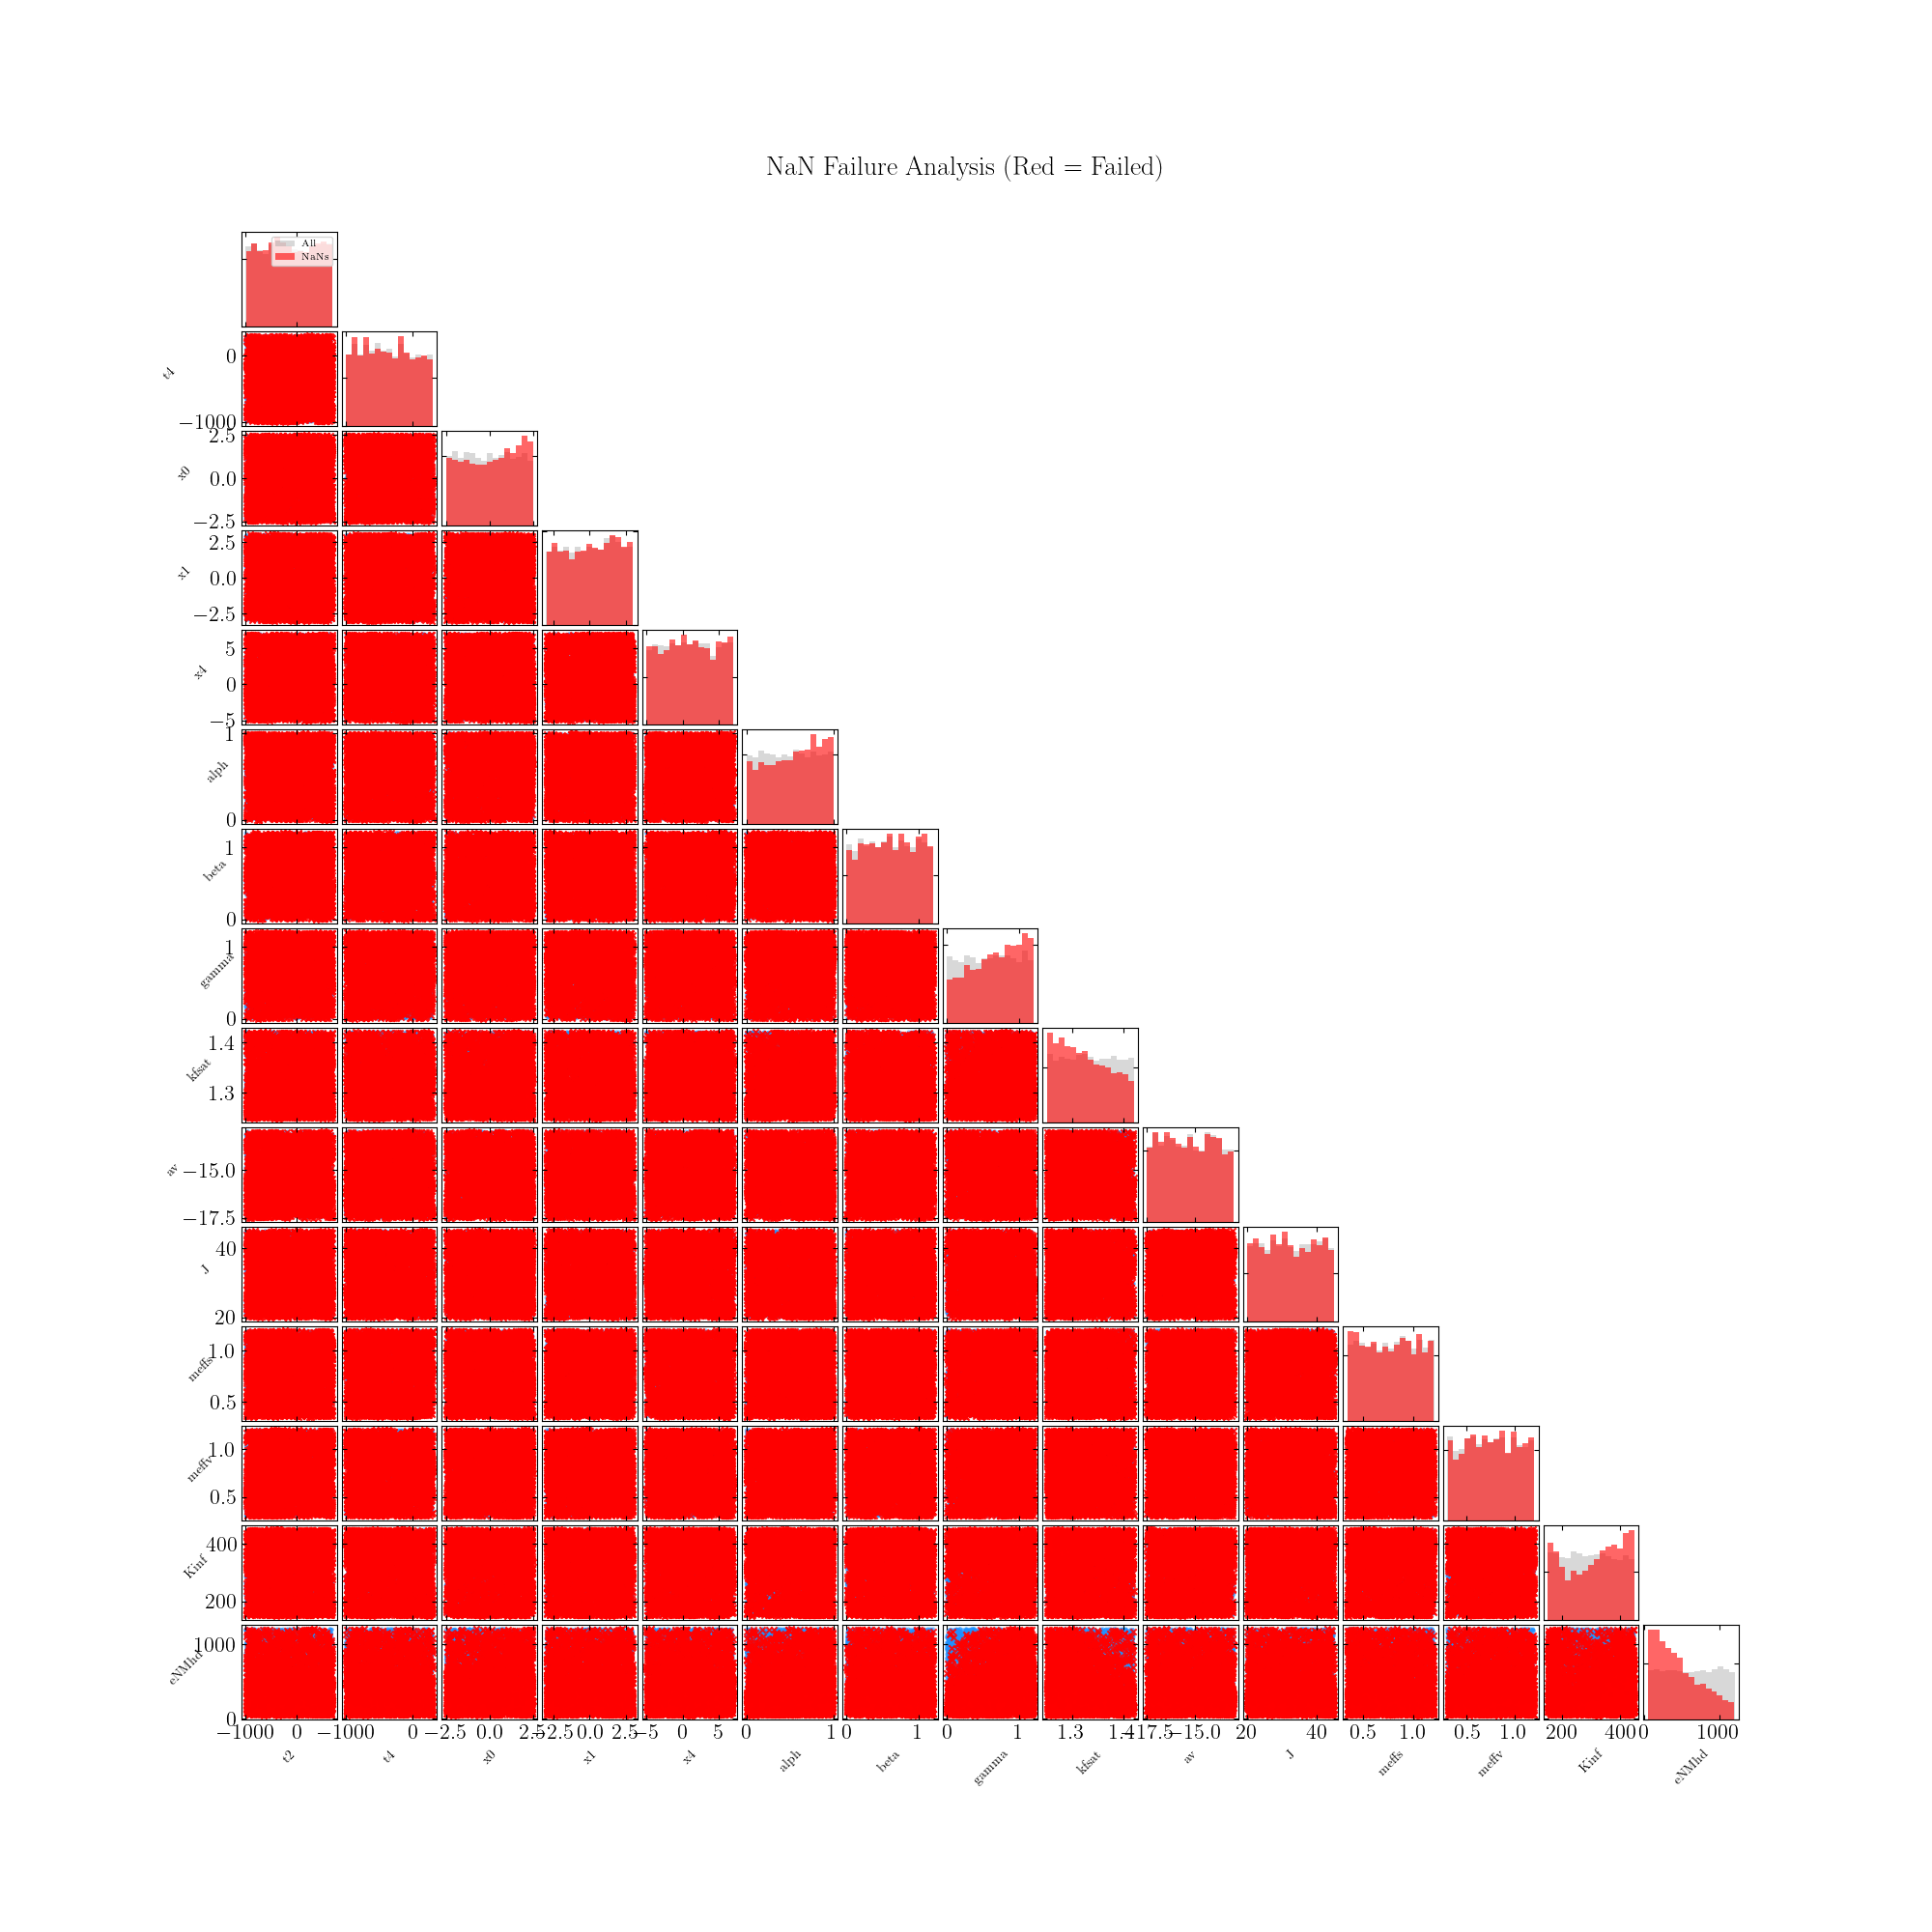

In [11]:
import numpy as np
import jax
import jax.numpy as jnp

# ---------------------------------------------------------
# MONKEY PATCH: Fix Dynamic Shape Error
# ---------------------------------------------------------
from jesterTOV.eos.crust import Crust


def safe_preprocess(self, n, p, e, min_density, max_density, filter_zero_pressure):
    return n, p, e


print("\U0001fa79 Applying JIT-safe monkey patch to Crust._preprocess...")
Crust._preprocess = safe_preprocess
print("\u2705 Patch applied. You can now run JAX JIT without dynamic shape errors.")

# ---------------------------------------------------------
# 1. Setup Parameters
# ---------------------------------------------------------
# inm_ranges = {
#     "t2": (-1e-2, 1e-1),
#     "t4": (-500, 0),
#     "x0": (-1.0, 1),
#     "x1": (-1.0, 5.0),
#     "x4": (-5.0, 7.0),
#     "alph": (0.05, 0.2),
#     "beta": (0.01, 0.5),
#     "gamma": (0.01, 0.3),
#     "kfsat": (1.32, 1.33),
#     "av": (-17.0, -14.5),
#     "J": (28.0, 40.0),
#     "meffs": (0.7, 1.0),
#     "meffv": (0.7, 1.0),
#     "Kinf": (210.0, 280.0),
#     "eNMhd": (200.0, 500.0),
# }

inm_ranges = {
    # Skyrme / generalized-Skyrme sector
    "t2": (-1000.0, 700.0),
    "t4": (-1000.0, 300.0),

    "x0": (-2.5, 2.5),
    "x1": (-3.0, 240.0),
    "x4": (-5.0, 7.0),

    # Density exponents.
    # Covers standard Skyrme-like alpha ~ 1/6, 1/3,
    # BSk-like alpha/gamma = 1/12,
    # and extended Skyrme eMSL-like beta = gamma = 1.
    "alph": (0.0, 1.0),
    "beta": (0.0, 1.2),
    "gamma": (0.0, 1.2),

    # Saturation Fermi momentum.
    # Corresponds roughly to broad n_sat ~ 0.13-0.19 fm^-3.
    "kfsat": (1.25, 1.42),

    # Energy per baryon at saturation.
    "av": (-17.5, -13.0),

    # Symmetry energy at saturation.
    "J": (20.0, 45.0),

    # Isoscalar and isovector effective masses.
    "meffs": (0.35, 1.20),
    "meffv": (0.30, 1.20),

    # Incompressibility.
    "Kinf": (150.0, 450.0),

    # High-density neutron-matter energy-like control parameter.
    # Keep broad unless you define the exact density and convention.
    "eNMhd": (50.0, 1200.0),
}

param_names = list(inm_ranges.keys())
n_tests = 5000
np.random.seed(42)

n_params = len(param_names)
bounds = np.array([inm_ranges[p] for p in param_names])
random_params = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_tests, n_params))

inm_batch = {
    name: jnp.array(random_params[:, i])
    for i, name in enumerate(param_names)
}

nsat = 0.16

@jax.jit
def run_batch_eos(inm_batch):
    def single_step(inm):
        return eos.construct_eos(
            inm,
            return_extra=True,
            calculate_durca=False,
        )
    batch_fn = jax.vmap(single_step)
    return batch_fn(inm_batch)

print(f"Running {n_tests} EOS constructions in parallel...")
results = run_batch_eos(inm_batch)

# ---------------------------------------------------------
# 5. Causality Cut and Unpacking
# ---------------------------------------------------------
ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, *extras = results

invalid_cs2 = (cs2_all < 0.0) | (cs2_all > 1.0) | jnp.isnan(cs2_all)
cut_mask = jnp.cumsum(invalid_cs2, axis=1) > 0

has_invalid = jnp.any(cut_mask, axis=1)
first_invalid_idx = jnp.argmax(cut_mask, axis=1)

n_cut = jnp.where(
    has_invalid,
    ns_all[jnp.arange(n_tests), first_invalid_idx],
    jnp.inf
)


def get_active_mask(arr_shape, base_mask, arr_ns=None, n_cut_thresholds=None):
    if arr_shape == base_mask.shape:
        return base_mask
    elif arr_ns is not None and n_cut_thresholds is not None:
        if arr_ns.ndim == 1:
            arr_ns = jnp.broadcast_to(arr_ns, (n_cut_thresholds.shape[0], arr_ns.shape[0]))
        return arr_ns >= jnp.expand_dims(n_cut_thresholds, axis=1)
    else:
        return jnp.zeros(arr_shape[:2], dtype=bool)


def apply_cut(arr, active_mask):
    if arr.ndim == 2:
        return jnp.where(active_mask, jnp.nan, arr)
    elif arr.ndim > 2:
        expanded_mask = jnp.expand_dims(active_mask, axis=tuple(range(2, arr.ndim)))
        return jnp.where(expanded_mask, jnp.nan, arr)
    return arr


ns_all = apply_cut(ns_all, cut_mask)
ps_all = apply_cut(ps_all, cut_mask)
hs_all = apply_cut(hs_all, cut_mask)
es_all = apply_cut(es_all, cut_mask)
dloge_dlogps_all = apply_cut(dloge_dlogps_all, cut_mask)
mu_all = apply_cut(mu_all, cut_mask)
cs2_all = apply_cut(cs2_all, cut_mask)

if extras:
    durca_all = extras[0]
    durca_ns_key = next((k for k in ['ns', 'n', 'n_b'] if k in durca_all), None)
    durca_ns_arr = durca_all[durca_ns_key] if durca_ns_key else None
    for key in list(durca_all.keys()):
        if hasattr(durca_all[key], 'shape'):
            active_mask = get_active_mask(durca_all[key].shape, cut_mask, durca_ns_arr, n_cut)
            durca_all[key] = apply_cut(durca_all[key], active_mask)
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2', 'durca']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, durca_all]
else:
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all]

print(f"\n{'='*60}")
print(f"NaN Detection Results (Unpacked {len(all_outputs)} variables):")
print("Note: NaNs in the acausal tail are expected and ignored.")
print(f"{'='*60}")

total_nan_tests = 0
global_nan_mask = jnp.zeros(n_tests, dtype=bool)


def check_true_nans(arr, active_mask):
    if arr.ndim == 2:
        return jnp.isnan(arr) & (~active_mask)
    elif arr.ndim > 2:
        expanded_mask = jnp.expand_dims(active_mask, axis=tuple(range(2, arr.ndim)))
        return jnp.isnan(arr) & (~expanded_mask)
    return jnp.isnan(arr)


for name, arr in zip(output_names, all_outputs):
    if isinstance(arr, dict):
        sub_ns_key = next((k for k in ['ns', 'n', 'n_b'] if k in arr), None)
        sub_ns_arr = arr[sub_ns_key] if sub_ns_key else None
        for sub_key, sub_arr in arr.items():
            if not hasattr(sub_arr, 'shape'):
                continue
            if sub_arr.ndim > 1:
                active_mask = get_active_mask(sub_arr.shape, cut_mask, sub_ns_arr, n_cut)
                true_nan_mask = check_true_nans(sub_arr, active_mask)
                row_is_nan = jnp.any(true_nan_mask, axis=tuple(range(1, sub_arr.ndim)))
            else:
                row_is_nan = jnp.isnan(sub_arr)
            global_nan_mask = global_nan_mask | row_is_nan
            nan_count = jnp.sum(row_is_nan)
            if nan_count > 0:
                indices = jnp.where(row_is_nan)[0]
                print(f"\nVariable '{name}['{sub_key}']': {nan_count} tests with true NaN")
                print(f"  Indices: {indices[:10].tolist()}{'...' if len(indices)>10 else ''}")
        continue

    if not hasattr(arr, 'ndim'):
        continue

    if arr.ndim > 1:
        true_nan_mask = check_true_nans(arr, cut_mask)
        row_is_nan = jnp.any(true_nan_mask, axis=tuple(range(1, arr.ndim)))
    else:
        row_is_nan = jnp.isnan(arr)
    global_nan_mask = global_nan_mask | row_is_nan
    nan_count = jnp.sum(row_is_nan)
    if nan_count > 0:
        indices = jnp.where(row_is_nan)[0]
        print(f"\nVariable '{name}': {nan_count} tests with true NaN")
        print(f"  Indices: {indices[:10].tolist()}{'...' if len(indices)>10 else ''}")

total_fails = jnp.sum(global_nan_mask)
successful = n_tests - total_fails

print(f"\n{'='*60}")
print(f"Summary: {successful}/{n_tests} successful, {total_fails}/{n_tests} failed.")
if total_fails > 0:
    first_fail_idx = int(jnp.where(global_nan_mask)[0][0])
    print(f"First failing parameters (Index {first_fail_idx}):")
    bad_params = {k: float(v[first_fail_idx]) for k, v in inm_batch.items()}
    print(bad_params)
print(f"{'='*60}")

# ---------------------------------------------------------
# 6. Corner Plot
# ---------------------------------------------------------
import matplotlib.pyplot as plt

param_matrix = np.stack([np.array(inm_batch[p]) for p in param_names], axis=1)
is_bad = np.array(global_nan_mask)
is_good = ~is_bad

n_dims = len(param_names)
fig, axes = plt.subplots(n_dims, n_dims, figsize=(20, 20))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_dims):
    for j in range(n_dims):
        ax = axes[i, j]
        x_data = param_matrix[:, j]
        y_data = param_matrix[:, i]
        if i == j:
            ax.hist(x_data, bins=15, color='gray', alpha=0.3, density=True, label='All')
            if np.sum(is_bad) > 0:
                ax.hist(x_data[is_bad], bins=15, color='red', alpha=0.6, density=True, label='NaNs')
            ax.set_yticklabels([])
            if i == 0:
                ax.legend(loc='upper right', fontsize='x-small')
        else:
            if i < j:
                ax.axis('off')
                continue
            ax.scatter(x_data[is_good], y_data[is_good], c='dodgerblue', s=10, alpha=0.5, edgecolor='none')
            if np.sum(is_bad) > 0:
                ax.scatter(x_data[is_bad], y_data[is_bad], c='red', s=20, alpha=0.9, marker='x')
        if i == n_dims - 1:
            ax.set_xlabel(param_names[j], fontsize=10, rotation=45)
        else:
            ax.set_xticklabels([])
        if j == 0 and i != j:
            ax.set_ylabel(param_names[i], fontsize=10, rotation=45)
        else:
            ax.set_yticklabels([])

plt.suptitle(f"NaN Failure Analysis (Red = Failed)", y=0.92, fontsize=20)
plt.show()


In [12]:
idx = 495
bad_params = {k: float(v[idx]) for k, v in inm_batch.items()}
print(bad_params)


{'t2': -374.89553618317655, 't4': -869.1940296106329, 'x0': -0.9518409499857712, 'x1': 0.9824061641636304, 'x4': 2.9894128176264516, 'alph': 0.28622430723999437, 'beta': 0.5521231518692256, 'gamma': 0.23213667361432497, 'kfsat': 1.285763253860072, 'av': -17.396288102170267, 'J': 42.418663747693614, 'meffs': 0.5291006653136703, 'meffv': 0.5047804892428169, 'Kinf': 233.88042979353955, 'eNMhd': 196.51928244974334}



Total NaN-free EOS: 2387
Physically valid EOS: 372
Physically invalid EOS: 2015


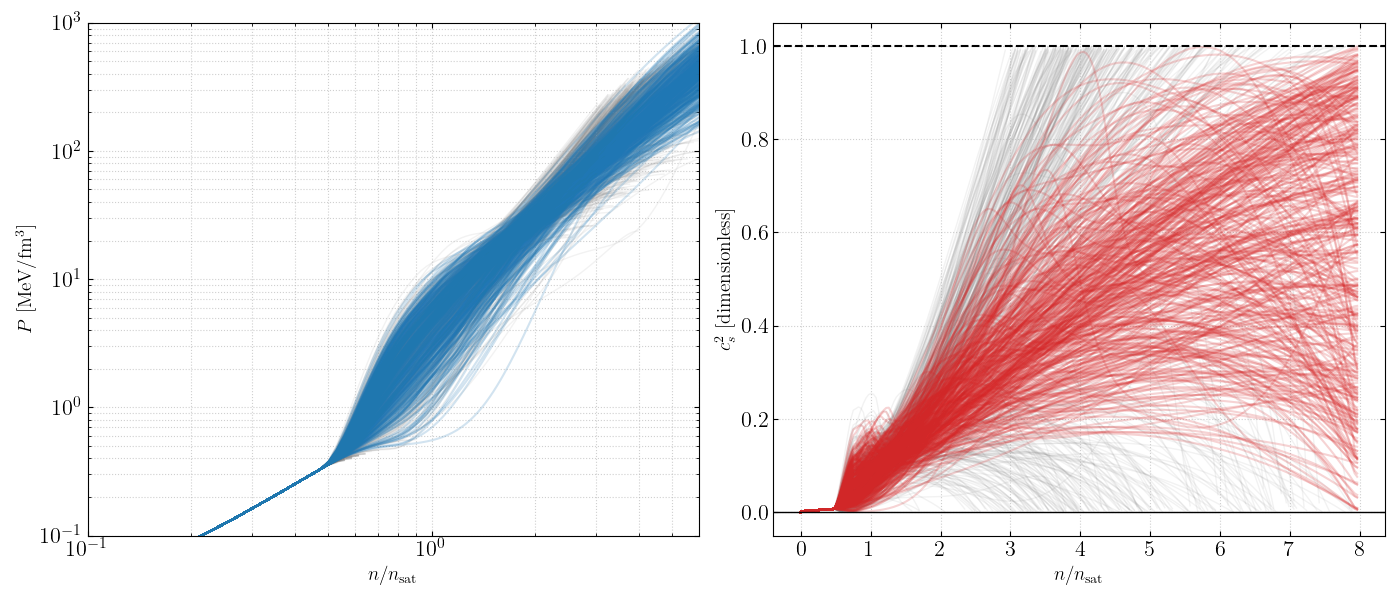

In [13]:
# 1. Base population: Filter out samples with NaNs during construction
base_indices = jnp.where(~global_nan_mask)[0]

# 2. Segregate by physics
valid_idxs = []
invalid_idxs = []

for idx in base_indices:
    if np.all((cs2_all[idx] >= 0.0) & (cs2_all[idx] <= 1.0)):
        valid_idxs.append(idx)
    else:
        invalid_idxs.append(idx)

valid_idxs = np.array(valid_idxs)
invalid_idxs = np.array(invalid_idxs)

print(f"\nTotal NaN-free EOS: {len(base_indices)}")
print(f"Physically valid EOS: {len(valid_idxs)}")
print(f"Physically invalid EOS: {len(invalid_idxs)}")

# 3. Subsample to avoid memory issues
n_plot_valid = min(500, len(valid_idxs))
n_plot_invalid = min(500, len(invalid_idxs))

plot_valid = np.random.choice(valid_idxs, size=n_plot_valid, replace=False) if n_plot_valid > 0 else []
plot_invalid = np.random.choice(invalid_idxs, size=n_plot_invalid, replace=False) if n_plot_invalid > 0 else []

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Pressure vs Density ---
ax_p = axes[0]

# Invalid EOS in background
for idx in plot_invalid:
    n_i = ns_all[idx]
    p_i = ps_all[idx] / utils.MeV_fm_inv3_to_geometric
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_p.plot(n_norm, p_i, color='gray', alpha=0.1, linewidth=1, zorder=1)

# Valid EOS in foreground
for idx in plot_valid:
    n_i = ns_all[idx]
    p_i = ps_all[idx] / utils.MeV_fm_inv3_to_geometric
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_p.plot(n_norm, p_i, color='tab:blue', alpha=0.2, linewidth=1.5, zorder=2)

ax_p.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=14)
ax_p.set_ylabel(r"$P$ [MeV/fm$^3$]", fontsize=14)
ax_p.grid(True, which='both', linestyle=':', alpha=0.6)
ax_p.set_yscale('log')
ax_p.set_xscale('log')
ax_p.set_ylim(1e-1, 1e3)
ax_p.set_xlim(1e-1, 6)

# --- Plot 2: Speed of Sound vs Density ---
ax_cs2 = axes[1]

for idx in plot_invalid:
    n_i = ns_all[idx]
    cs2_i = cs2_all[idx]
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_cs2.plot(n_norm, cs2_i, color='gray', alpha=0.1, linewidth=1, zorder=1)

for idx in plot_valid:
    n_i = ns_all[idx]
    cs2_i = cs2_all[idx]
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_cs2.plot(n_norm, cs2_i, color='tab:red', alpha=0.2, linewidth=1.5, zorder=2)

ax_cs2.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label=r'Causality ($c_s^2=1$)')
ax_cs2.axhline(0.0, color='black', linestyle='-', linewidth=1.0)

ax_cs2.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=14)
ax_cs2.set_ylabel(r"$c_s^2$ [dimensionless]", fontsize=14)
ax_cs2.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
plt.close()


In [14]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Base population: Filter out samples with NaNs during construction
base_indices = jnp.where(~global_nan_mask)[0]

# 2. Segregate by physics
valid_idxs = []
invalid_idxs = []

for idx in base_indices:
    if np.all((cs2_all[idx] >= 0.0) & (cs2_all[idx] <= 1.0)):
        valid_idxs.append(idx)
    else:
        invalid_idxs.append(idx)

valid_idxs = np.array(valid_idxs)
invalid_idxs = np.array(invalid_idxs)

print(f"\nTotal NaN-free EOS: {len(base_indices)}")
print(f"Physically valid EOS: {len(valid_idxs)}")
print(f"Physically invalid EOS: {len(invalid_idxs)}")

# 3. Subsample to avoid memory issues
n_plot_valid = min(500, len(valid_idxs))
n_plot_invalid = min(500, len(invalid_idxs))

plot_valid = np.random.choice(valid_idxs, size=n_plot_valid, replace=False) if n_plot_valid > 0 else []
plot_invalid = np.random.choice(invalid_idxs, size=n_plot_invalid, replace=False) if n_plot_invalid > 0 else []

# CREATE WIDGET OUTPUT BOX TO CATCH LOGS
log_out = widgets.Output()

# Force white background for dark mode compatibility
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Plot 1: Pressure vs Density
ax_p = axes[0]
ax_p.set_facecolor('white')

for idx in plot_invalid:
    n_i = ns_all[idx]
    p_i = ps_all[idx] / utils.MeV_fm_inv3_to_geometric
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_p.plot(n_norm, p_i, color='gray', alpha=0.1, linewidth=1, zorder=1, picker=5, gid=str(idx))

for idx in plot_valid:
    n_i = ns_all[idx]
    p_i = ps_all[idx] / utils.MeV_fm_inv3_to_geometric
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_p.plot(n_norm, p_i, color='tab:blue', alpha=0.2, linewidth=1.5, zorder=2, picker=5, gid=str(idx))

ax_p.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=14)
ax_p.set_ylabel(r"$P$ [MeV/fm$^3$]", fontsize=14)
ax_p.grid(True, which='both', linestyle=':', alpha=0.6)
ax_p.set_yscale('log')
ax_p.set_xscale('log')
ax_p.set_ylim(1e-1, 1e3)
ax_p.set_xlim(1e-1, 6)

# Plot 2: Speed of Sound vs Density
ax_cs2 = axes[1]
ax_cs2.set_facecolor('white')

for idx in plot_invalid:
    n_i = ns_all[idx]
    cs2_i = cs2_all[idx]
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_cs2.plot(n_norm, cs2_i, color='gray', alpha=0.1, linewidth=1, zorder=1, picker=5, gid=str(idx))

for idx in plot_valid:
    n_i = ns_all[idx]
    cs2_i = cs2_all[idx]
    n_norm = n_i / utils.fm_inv3_to_geometric / nsat
    ax_cs2.plot(n_norm, cs2_i, color='tab:red', alpha=0.2, linewidth=1.5, zorder=2, picker=5, gid=str(idx))

ax_cs2.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label=r'Causality ($c_s^2=1$)')
ax_cs2.axhline(0.0, color='black', linestyle='-', linewidth=1.0)

ax_cs2.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=14)
ax_cs2.set_ylabel(r"$c_s^2$ [dimensionless]", fontsize=14)
ax_cs2.grid(True, which='both', linestyle=':', alpha=0.6)

# Event handler for line picking
def on_pick(event):
    # Strictly filter out hover events, only process explicit mouse clicks
    if event.mouseevent.name != 'button_press_event':
        return
        
    line = event.artist
    idx_str = line.get_gid()
    if idx_str is not None:
        idx = int(idx_str)
        
        # ROUTE PRINT TO WIDGET OUTPUT
        with log_out:
            print(f">>> [Selected EOS Index] {idx} clicked!")
        
        line.set_alpha(1.0)
        line.set_linewidth(2.5)
        line.set_color('magenta')
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)

plt.tight_layout()

# DISPLAY EVERYTHING
display(widgets.VBox([log_out, fig.canvas]))


Total NaN-free EOS: 2387
Physically valid EOS: 372
Physically invalid EOS: 2015
